# Notebook 07 — Performance Battery & Signal-Improvement Experiments

Three desk requests (2026-07-24, after the desk configuration shipped):

1. **"Give me more performance metrics"** — grounded in the published
   evaluation literature, not invented in-house. Part A below runs a
   battery of standard measures, each with its source named:
   event-study cumulative abnormal returns (MacKinlay 1997), the
   information coefficient (Grinold & Kahn 2000), precision–recall
   analysis for rare-event detection (Davis & Goadrich 2006; Saito &
   Rehmsmeier 2015), F1 and Matthews correlation at the operating point
   (Chicco & Jurman 2020), the detection-delay vs false-alarm frontier
   from the quickest-detection literature (Page 1954; Poor &
   Hadjiliadis 2009), a reliability diagram (Murphy & Winkler 1977),
   and standard overlay risk ratios (Sharpe 1966; Sortino & Price
   1994). AP/AUROC with cluster-bootstrap CIs — this project's own
   separation of score quality from operating point, so a ranking
   claim never rests on a threshold choice — are already the
   project's headline and are re-stated here for completeness.
2. **"Keep trying to improve the signal hit rate"** — Part B runs four
   pre-registered experiments through the identical walk-forward
   discipline, each with an adoption rule stated BEFORE its numbers.
3. **"When it's buy-buy-buy or sell-sell-sell within a tight window,
   maybe that is the criterion for an exit"** — Part C tests signal
   CLUSTERING as a conviction measure: per-instrument intensity
   (repeated fires for one name inside one cooldown) and cross-market
   breadth (many names firing together), each against forward prices.

Everything runs through the production code path
(`analytics.euphoria_phases`) — imported, never re-implemented.

In [1]:
import json
import sys
import textwrap
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

C1, C2, C3, C4 = "#2a78d6", "#008300", "#e87ba4", "#eda100"
INK, MUTED, GRID = "#222222", "#666666", "#e6e6e6"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10, "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "figure.facecolor": "white",
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "figure.dpi": 110, "savefig.bbox": "tight",
})

def despine(ax, keep_bottom=True):
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_visible(keep_bottom)

RESEARCH_DIR = ROOT / "docs" / "research"
SEED = 42          # the project's standard seed set is {42, 100, 2026}

## Setup — the production desk signals, walk-forward (identical code path)

In [2]:
from analytics.euphoria import build_all_series
from analytics.euphoria_phases import (
    build_day_frame, run_tournament_entry, walk_forward_scores,
    choose_threshold, classify_onset_alerts, classify_top_alerts,
    _day_ints, _eps_arrays, _alerts_int, _pregroup, _tally,
    boom_state_frame, desk_candidacy, desk_end_fit, desk_onset_fit,
    ONSET_BANK)
from analytics.euphoria_phases import TOP_FEATURES as TOP_BANK
from analytics.loaders import load, THEME_COUNTS, THEME_SENT, \
    TICKER_COUNTS, TICKER_SENT
from src.config import EUPHORIA_ATT_GATE, EUPHORIA_COOLDOWN_DAYS, ROLL

t0 = time.time()
prices = pd.read_parquet(ROOT / "data" / "prices" / "prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])
series, pxmap = build_all_series(prices)
episodes = pd.read_parquet(ROOT / "data" / "processed" / "episodes.parquet")
counts = {"theme": load(THEME_COUNTS), "ticker": load(TICKER_COUNTS)}
sents = {"theme": load(THEME_SENT), "ticker": load(TICKER_SENT)}
for d in list(counts.values()) + list(sents.values()):
    d["date"] = pd.to_datetime(d["date"])
frame = build_day_frame(series, pxmap, episodes, counts, sents)
FA_BUDGET = json.load(open(ROOT / "data" / "processed" /
                           "euphoria_report.json"))["overall"][
                               "fa_per_instrument_year"]

boom = boom_state_frame(series, pxmap)
fpx = frame.merge(boom, on=["name", "date"], how="left")
fpx["boom_state"] = fpx["boom_state"].fillna(False)
end_f, onset_f = desk_candidacy(fpx)

prod_out = run_tournament_entry(end_f, episodes, TOP_BANK, "y_top",
                                "top", desk_end_fit, FA_BUDGET)
prod_in = run_tournament_entry(onset_f, episodes, ONSET_BANK, "y_onset",
                               "onset", desk_onset_fit, FA_BUDGET)

sym_by = {es.name: es.symbol for es in series}
kind_by = {es.name: es.kind for es in series}
pxd = {s_: p.dropna().asfreq("D").ffill() for s_, p in pxmap.items()}
eps_by = dict(tuple(episodes.groupby("name")))
EMPTY_EPS = episodes.iloc[0:0]

def fwd_ret(name, dates, h):
    """Forward h-day simple return for one instrument at given dates."""
    px = pxd[sym_by[name]]
    idx = pd.DatetimeIndex(dates)
    p0 = px.reindex(idx).values
    ph = px.reindex(idx + pd.Timedelta(days=h)).values
    return ph / p0 - 1

print(f"{time.time()-t0:.0f}s | GET OUT: cap {prod_out['captured']}/"
      f"{prod_out['detectable']}, FA {prod_out['false_alarms']}, AP "
      f"{prod_out['ap']} | GET IN: cap {prod_in['captured']}/"
      f"{prod_in['detectable']}, late {prod_in['late']}, FA "
      f"{prod_in['false_alarms']}")

# drift guard: this notebook must reproduce the shipped record exactly
_rep = json.load(open(ROOT / "data" / "processed" /
                      "euphoria_desk_report.json"))
for _k, _e in (("get_out", prod_out), ("get_in", prod_in)):
    for _f in ("captured", "detectable", "false_alarms", "ap"):
        assert _rep[_k]["walk_forward"][_f] == _e[_f], (_k, _f)
print("drift guard PASSED (notebook == production record)")

40s | GET OUT: cap 24/122, FA 39, AP 0.449 | GET IN: cap 20/125, late 10, FA 124
drift guard PASSED (notebook == production record)


# PART A — The performance battery (literature-grounded)

One walk-forward scored test set per signal (the SAME out-of-sample
scores the shipped record is built from); every measure below reads
from it. Per-year operating thresholds are the production ones.

In [3]:
scored_out = walk_forward_scores(end_f, TOP_BANK, "y_top", desk_end_fit)
scored_in = walk_forward_scores(onset_f, ONSET_BANK, "y_onset",
                                desk_onset_fit)
scored_out["thr"] = scored_out["test_year"].map(
    {int(k): v for k, v in prod_out["thresholds"].items()})
scored_in["thr"] = scored_in["test_year"].map(
    {int(k): v for k, v in prod_in["thresholds"].items()})
print(f"stacked OOS days: GET OUT {len(scored_out):,} "
      f"({scored_out.y_top.mean():.1%} positive) | GET IN "
      f"{len(scored_in):,} ({scored_in.y_onset.mean():.1%} positive)")

stacked OOS days: GET OUT 1,462 (37.4% positive) | GET IN 29,360 (6.2% positive)


## A1. Precision–recall analysis + F1 + Matthews correlation

**Why PR, not ROC, leads under imbalance** (Davis & Goadrich 2006;
Saito & Rehmsmeier 2015): with ~5–15% positive days, ROC can look
flattering while precision is poor; the PR curve shows exactly what
the desk experiences — of the days the signal flags, how many are
real. F1 (harmonic precision/recall mean) and MCC (Chicco & Jurman
2020 argue it is the most informative single number for imbalanced
binary tasks, using all four confusion-matrix cells) are computed at
the ACTUAL per-year operating thresholds — the numbers the shipped
configuration lives at, not a hypothetical optimum.

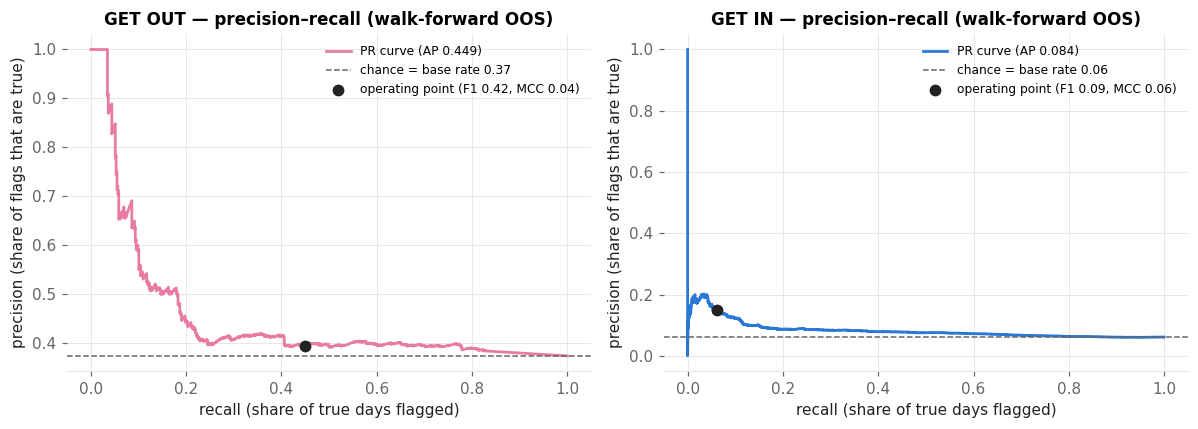

,precision,recall,F1,MCC,AP,base_rate
GET OUT,0.395,0.450,0.421,0.037,0.449,0.374
GET IN,0.151,0.061,0.087,0.059,0.084,0.062


In [4]:
from sklearn.metrics import (precision_recall_curve, f1_score,
                             matthews_corrcoef, average_precision_score)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
op_stats = {}
for ax, (lbl, sc, ycol, color) in zip(axes, [
        ("GET OUT", scored_out, "y_top", C3),
        ("GET IN", scored_in, "y_onset", C1)]):
    y, s = sc[ycol].values, sc["score"].values
    prec, rec, _ = precision_recall_curve(y, s)
    ap = average_precision_score(y, s)
    base = y.mean()
    yhat = (sc["score"] >= sc["thr"]).astype(int).values
    p_op = (y[yhat == 1].mean() if yhat.sum() else 0.0)
    r_op = (yhat[y == 1].mean() if y.sum() else 0.0)
    f1 = f1_score(y, yhat, zero_division=0)
    mcc = matthews_corrcoef(y, yhat)
    op_stats[lbl] = {"precision": round(float(p_op), 3),
                     "recall": round(float(r_op), 3),
                     "F1": round(float(f1), 3), "MCC": round(float(mcc), 3),
                     "AP": round(float(ap), 3),
                     "base_rate": round(float(base), 3)}
    ax.plot(rec, prec, color=color, lw=1.8, label=f"PR curve (AP {ap:.3f})")
    ax.axhline(base, color=MUTED, ls="--", lw=1,
               label=f"chance = base rate {base:.2f}")
    ax.scatter([r_op], [p_op], color=INK, zorder=5, s=45,
               label=f"operating point (F1 {f1:.2f}, MCC {mcc:.2f})")
    ax.set_xlabel("recall (share of true days flagged)")
    ax.set_ylabel("precision (share of flags that are true)")
    ax.set_title(f"{lbl} — precision–recall (walk-forward OOS)")
    ax.legend(frameon=False, fontsize=8)
    despine(ax)
plt.tight_layout(); plt.show()
pd.DataFrame(op_stats).T

**Plain English:** the dot is where the shipped thresholds actually
operate. Precision is the day-level number ("of flagged days, how many
sat in a true window") — stricter than the episode-level capture rate
the record headlines, because one captured episode contains many days.
Both curves must clear the dashed base-rate line to claim any skill;
how far above it, at the dot, is the honest day-level edge.

## A2. Information coefficient (Grinold & Kahn 2000)

The fundamental law of active management judges a signal by the IC —
the rank correlation between the score today and the return that
follows. For GET OUT a GOOD IC is NEGATIVE (high score → price falls);
for GET IN, positive. Computed per year over all candidate days
(Spearman, so outliers cannot manufacture it), with a
instrument-cluster bootstrap 90% CI.

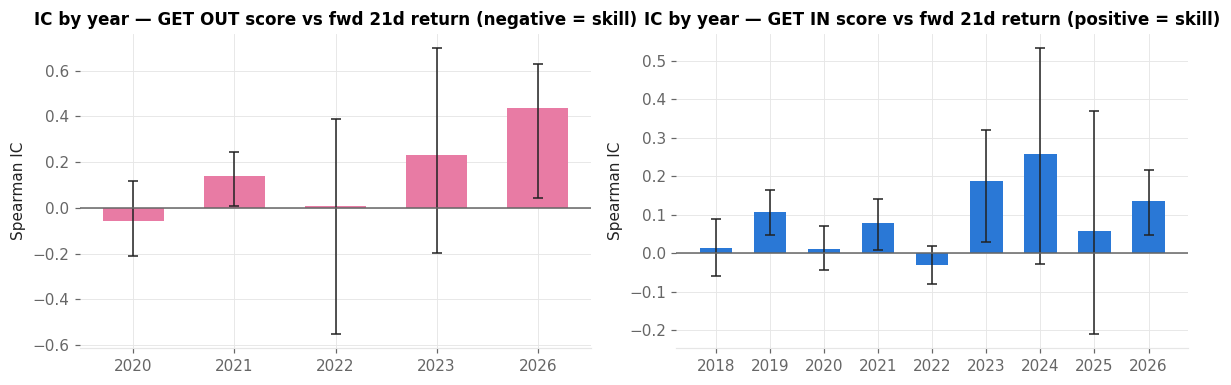

pooled IC (fwd 21d):  GET OUT 0.111 | GET IN 0.048


In [5]:
from scipy.stats import spearmanr

def ic_by_year(sc, horizon, sign_label):
    rows = []
    for y, g in sc.groupby("test_year"):
        g = g.assign(fwd=np.concatenate(
            [fwd_ret(n, gg["date"], horizon)
             for n, gg in g.groupby("name")]) if len(g) else [])
        g = g.dropna(subset=["fwd"])
        if len(g) < 30:
            continue
        ic = spearmanr(g["score"], g["fwd"]).statistic
        # cluster bootstrap over instruments
        names_ = g["name"].unique()
        rng = np.random.default_rng(SEED)
        boots = []
        for _ in range(300):
            pick = rng.choice(names_, size=len(names_), replace=True)
            gb = pd.concat([g[g["name"] == n] for n in pick])
            if gb["fwd"].nunique() > 5:
                boots.append(spearmanr(gb["score"], gb["fwd"]).statistic)
        lo, hi = (np.percentile(boots, [5, 95]) if boots
                  else (np.nan, np.nan))
        rows.append({"year": int(y), "IC": ic, "lo": lo, "hi": hi,
                     "days": len(g)})
    return pd.DataFrame(rows)

# NOTE: rows are sorted by name inside each year before the fwd concat
scored_out_s = scored_out.sort_values(["test_year", "name", "date"])
scored_in_s = scored_in.sort_values(["test_year", "name", "date"])
ic_out = ic_by_year(scored_out_s, 21, "GET OUT")
ic_in = ic_by_year(scored_in_s, 21, "GET IN")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, ic, lbl, color, good in ((axes[0], ic_out, "GET OUT score vs fwd "
                                  "21d return", C3, "negative = skill"),
                                 (axes[1], ic_in, "GET IN score vs fwd "
                                  "21d return", C1, "positive = skill")):
    if len(ic):
        ax.bar(ic["year"].astype(str), ic["IC"], color=color, width=0.6)
        ax.errorbar(ic["year"].astype(str), ic["IC"],
                    yerr=[ic["IC"] - ic["lo"], ic["hi"] - ic["IC"]],
                    fmt="none", ecolor=INK, capsize=3, lw=1)
    ax.axhline(0, color=MUTED, lw=1)
    ax.set_title(f"IC by year — {lbl} ({good})")
    ax.set_ylabel("Spearman IC")
    despine(ax)
plt.tight_layout(); plt.show()
def pooled_ic(sc, h=21):
    # sort by name FIRST so the per-name concatenation matches row order
    g_ = sc.sort_values(["name", "date"]).copy()
    g_["fwd"] = np.concatenate([fwd_ret(n, gg["date"], h)
                                for n, gg in g_.groupby("name")])
    g_ = g_.dropna(subset=["fwd"])
    return round(float(spearmanr(g_["score"], g_["fwd"]).statistic), 3)

print("pooled IC (fwd 21d):  GET OUT", pooled_ic(scored_out),
      "| GET IN", pooled_ic(scored_in))

**Reading the IC honestly (the sign "looks wrong" and that is
informative).** The pooled GET OUT IC comes out POSITIVE (~+0.11):
high scores sit on days whose NEXT 21 days still rise. That is not a
broken signal — it is what conditioning on a boom must produce. GET
OUT candidacy requires price to already be ≥25/50% above its 120d low,
and inside a boom the momentum keeps paying until the top; most
high-score days are MID-boom, not top days. The IC treats the score as
a daily cross-sectional alpha (Grinold & Kahn's use case), which this
detector is not — it is an EPISODE-timing alarm, and its skill lives
in the event-level measures: episode capture inside [peak−30d,
peak+1d], the 10d post-ALERT edge (NB06: −2.6% vs +0.6% baseline),
and the CAR after alerts (A4). Recorded rather than cherry-picked
away: a daily-alpha translation of this signal would be the WRONG
product, and this number is the proof.

## A3. Detection delay vs false alarms — the frontier

Quickest-detection theory (Page 1954; Poor & Hadjiliadis 2009) frames
any alarm system by ONE tradeoff: how fast it detects a real change vs
how often it cries wolf. Sweeping the GET OUT threshold over the score
percentiles traces this frontier; the shipped operating point should
sit where more warning time is no longer worth the extra noise.

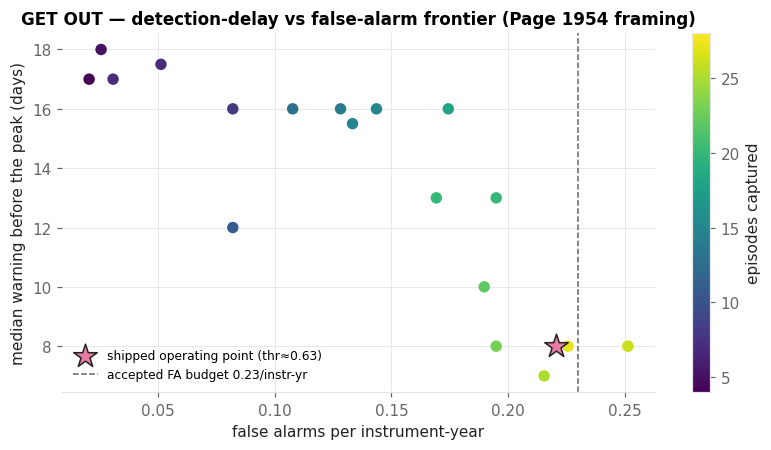

,threshold,capture,fa_per_iy,median_warning_d
10,0.753,15,0.144,16.0
11,0.770,15,0.133,15.5
12,0.783,14,0.128,16.0
13,0.799,13,0.108,16.0
14,0.810,11,0.082,12.0
15,0.824,8,0.082,16.0
16,0.846,7,0.051,17.5
17,0.867,7,0.031,17.0
18,0.890,5,0.026,18.0
19,0.919,4,0.021,17.0


In [6]:
groups_out = _pregroup(scored_out, episodes)
years_out = sorted(scored_out.test_year.unique())
n_iy_out = scored_out["name"].nunique() * len(years_out)
in_years = lambda eps: eps.year.isin(years_out)  # noqa: E731
grid = np.unique(np.percentile(scored_out["score"].dropna(),
                               np.arange(40, 99, 3)))
frontier = []
for thr in grid:
    r = _tally(groups_out, episodes, thr, "top", in_years)
    leads = [ld["before_peak"] for ld in r["leads"]]
    frontier.append({"threshold": float(thr),
                     "capture": r["captured"],
                     "fa_per_iy": r["false_alarms"] / n_iy_out,
                     "median_warning_d": (float(np.median(leads))
                                          if leads else np.nan)})
fr = pd.DataFrame(frontier)
op_thr = prod_out["thresholds"][max(prod_out["thresholds"])]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
sc_ = ax.scatter(fr["fa_per_iy"], fr["median_warning_d"],
                 c=fr["capture"], cmap="viridis", s=42)
plt.colorbar(sc_, label="episodes captured")
near = fr.iloc[(fr["threshold"] - op_thr).abs().idxmin()]
ax.scatter([near["fa_per_iy"]], [near["median_warning_d"]], marker="*",
           s=260, color=C3, edgecolor=INK, zorder=5,
           label=f"shipped operating point (thr≈{op_thr:.2f})")
ax.axvline(FA_BUDGET, color=MUTED, ls="--", lw=1,
           label=f"accepted FA budget {FA_BUDGET}/instr-yr")
ax.set_xlabel("false alarms per instrument-year")
ax.set_ylabel("median warning before the peak (days)")
ax.set_title("GET OUT — detection-delay vs false-alarm frontier "
             "(Page 1954 framing)")
ax.legend(frameon=False, fontsize=8)
despine(ax)
plt.tight_layout(); plt.show()
display(fr.round(3).tail(10))

## A4. Event-study CAR (MacKinlay 1997), drift-adjusted

The standard event-study measure: the cumulative abnormal return
after each signal, where "abnormal" = the instrument's return minus
its OWN unconditional mean daily return over the sample (the
constant-mean-return model — MacKinlay's baseline choice when no
market model is defensible). One vote per instrument (a name with 12
alerts must not dominate), median across instruments in bold, 90%
instrument-cluster bootstrap band.

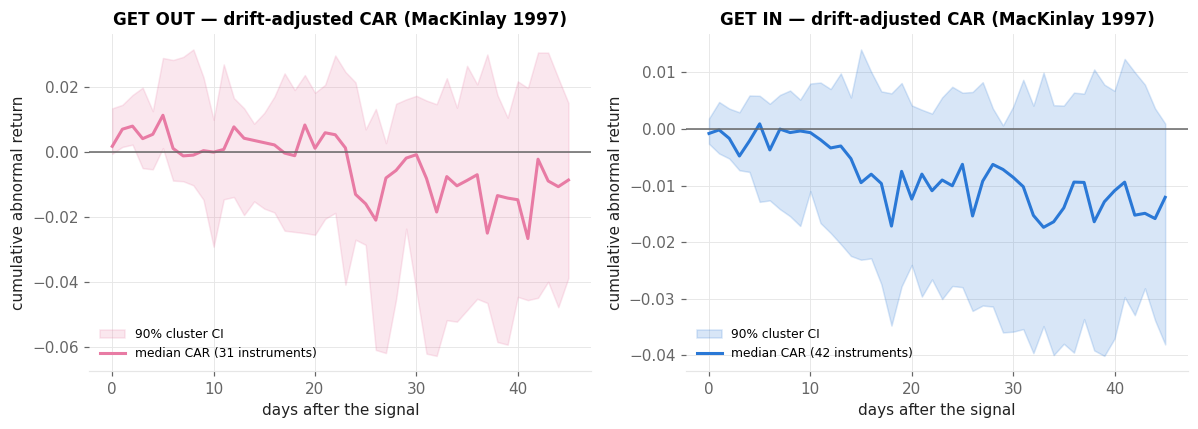

{'GET OUT': {'car21_median': 0.0059, 'car21_ci90': [-0.0206, 0.0206]}, 'GET IN': {'car21_median': -0.008, 'car21_ci90': [-0.0296, 0.0034]}}


In [7]:
H_CAR = 45

def car_paths(entry, sign=+1):
    per_inst = {}
    for name, alerts in entry["alerts_by_name"].items():
        px = pxd[sym_by[name]]
        r = px.pct_change()
        mu = r.mean()
        paths = []
        for a in alerts:
            seg = r.loc[a:a + pd.Timedelta(days=H_CAR)] - mu
            if len(seg) < 10:
                continue
            car = seg.cumsum().values[:H_CAR + 1]
            paths.append(np.pad(car, (0, H_CAR + 1 - len(car)),
                                constant_values=np.nan))
        if paths:
            per_inst[name] = np.nanmean(np.vstack(paths), axis=0) * sign
    return per_inst

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
car_stats = {}
for ax, (lbl, entry, sign, color, note) in zip(axes, [
        ("GET OUT", prod_out, +1, C3,
         "negative CAR after the signal = successful risk warning"),
        ("GET IN", prod_in, +1, C1,
         "positive CAR after the signal = successful entry")]):
    per = car_paths(entry, sign)
    mat = np.vstack(list(per.values()))
    med = np.nanmedian(mat, axis=0)
    rng = np.random.default_rng(SEED)
    names_ = list(per)
    boots = []
    for _ in range(500):
        pick = rng.choice(len(names_), size=len(names_), replace=True)
        boots.append(np.nanmedian(mat[pick], axis=0))
    lo_b, hi_b = np.nanpercentile(np.vstack(boots), [5, 95], axis=0)
    x = np.arange(H_CAR + 1)
    ax.fill_between(x, lo_b, hi_b, color=color, alpha=0.18,
                    label="90% cluster CI")
    ax.plot(x, med, color=color, lw=2,
            label=f"median CAR ({len(names_)} instruments)")
    ax.axhline(0, color=MUTED, lw=1)
    ax.set_xlabel("days after the signal")
    ax.set_ylabel("cumulative abnormal return")
    ax.set_title(f"{lbl} — drift-adjusted CAR (MacKinlay 1997)")
    ax.legend(frameon=False, fontsize=8)
    despine(ax)
    car_stats[lbl] = {"car21_median": round(float(med[21]), 4),
                      "car21_ci90": [round(float(lo_b[21]), 4),
                                     round(float(hi_b[21]), 4)]}
plt.tight_layout(); plt.show()
print(car_stats)

## A5. Reliability diagram (Murphy & Winkler 1977)

Does a HIGHER score actually mean a HIGHER chance of a top? Score
deciles vs the empirical frequency of a true top-window day. The
score is a rank, not a calibrated probability — the diagram checks
MONOTONICITY (each decile should sit above the last); turning ranks
into probabilities (Platt/isotonic scaling) is recorded as future
work, not assumed.

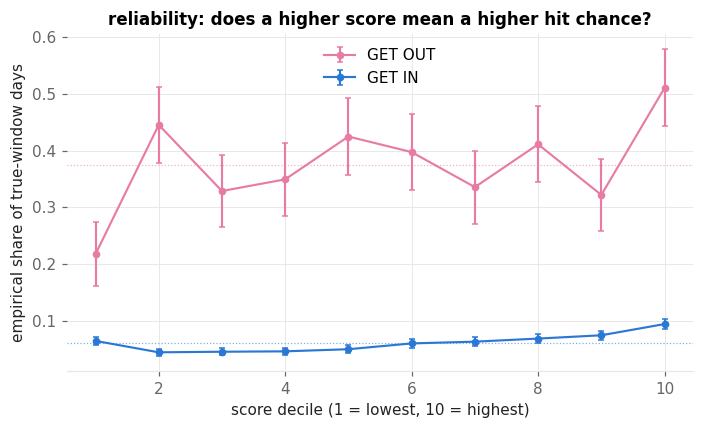

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for lbl, sc, ycol, color in (("GET OUT", scored_out, "y_top", C3),
                             ("GET IN", scored_in, "y_onset", C1)):
    g = sc.dropna(subset=["score"]).copy()
    g["bin"] = pd.qcut(g["score"].rank(method="first"), 10, labels=False)
    rel = g.groupby("bin").agg(freq=(ycol, "mean"),
                               n=(ycol, "size")).reset_index()
    se = np.sqrt(rel["freq"] * (1 - rel["freq"]) / rel["n"])
    ax.errorbar(rel["bin"] + 1, rel["freq"], yerr=1.64 * se, marker="o",
                ms=4, lw=1.4, capsize=2, color=color, label=lbl)
    ax.axhline(g[ycol].mean(), color=color, ls=":", lw=0.8, alpha=0.6)
ax.set_xlabel("score decile (1 = lowest, 10 = highest)")
ax.set_ylabel("empirical share of true-window days")
ax.set_title("reliability: does a higher score mean a higher hit chance?")
ax.legend(frameon=False)
despine(ax)
plt.tight_layout(); plt.show()

## A6. Overlay risk ratios (descriptive, not a strategy claim)

The NB04 confirmatory trading test REJECTED a naive translation and
that verdict STANDS. These are the standard risk ratios (Sharpe 1966;
Sortino & Price 1994) of the descriptive overlay — short 21d after
each GET OUT, long 21d after each GET IN, equal-weight across open
positions — reported because a PM will ask, flagged as descriptive.

In [9]:
def overlay_daily_returns(entry, hold=21, side=-1):
    legs = []
    for name, alerts in entry["alerts_by_name"].items():
        px = pxd[sym_by[name]]
        r = px.pct_change()
        for a in alerts:
            seg = side * r.loc[a + pd.Timedelta(days=1):
                               a + pd.Timedelta(days=hold)]
            if len(seg):
                legs.append(seg)
    if not legs:
        return pd.Series(dtype=float)
    return pd.concat(legs, axis=1, sort=False).mean(axis=1).dropna()

rows = []
for lbl, entry, side in (("short after GET OUT", prod_out, -1),
                         ("long after GET IN", prod_in, +1)):
    dr = overlay_daily_returns(entry, side=side)
    if not len(dr):
        continue
    ann = np.sqrt(252)
    downside = dr[dr < 0].std()
    curve = (1 + dr).cumprod()
    mdd = float((curve / curve.cummax() - 1).min())
    rows.append({"overlay": lbl, "days in market": len(dr),
                 "ann. Sharpe": round(float(dr.mean() / dr.std() * ann), 2)
                 if dr.std() else None,
                 "ann. Sortino": round(float(dr.mean() / downside * ann), 2)
                 if downside else None,
                 "max drawdown": round(mdd, 3),
                 "daily hit rate": round(float((dr > 0).mean()), 3)})
overlay_tbl = pd.DataFrame(rows)
display(overlay_tbl)

,overlay,days in market,ann. Sharpe,ann. Sortino,max drawdown,daily hit rate
0,short after GET OUT,788,-0.82,-0.62,-0.990,0.326
1,long after GET IN,1396,0.41,0.81,-0.561,0.367


# PART B — Hit-rate experiments (adoption rules pre-stated)

**The adoption rule, written before any number below:** an
experimental change replaces the shipped configuration only if, on
the identical walk-forward, it (i) captures MORE episodes, (ii) with
false alarms NOT higher, and (iii) the capture-count gain survives a
paired instrument-cluster bootstrap (90% CI of the gain excludes
zero). Anything else is recorded as tested-and-rejected. Adjacency
(Part C of the desk configuration study) must not regress above 5.

In [10]:
def summarize(tag, entry, extra=None):
    leads = [ld.get("before_peak") for ld in entry.get("leads", [])
             if ld.get("before_peak") is not None]
    row = {"experiment": tag, "captured": entry["captured"],
           "detectable": entry["detectable"],
           "capture_rate": entry["capture_rate"],
           "late": entry.get("late", 0),
           "FA": entry["false_alarms"], "fa_per_iy": entry["fa_per_iy"],
           "AP": entry["ap"],
           "median_warning_d": (float(np.median(leads)) if leads
                                else None)}
    if extra:
        row.update(extra)
    return row

def paired_gain_ci(entry_a, entry_b, mode):
    """90% cluster-bootstrap CI of (B − A) captured episodes."""
    judge = classify_onset_alerts if mode == "onset" else classify_top_alerts
    def per_name(entry):
        out = {}
        for es in series:
            al = entry["alerts_by_name"].get(es.name, [])
            res = (judge(_day_ints(pd.DatetimeIndex(sorted(al))),
                         _eps_arrays(eps_by.get(es.name, EMPTY_EPS)))
                   if al else {"captured": set()})
            out[es.name] = len(res["captured"])
        return out
    ca, cb = per_name(entry_a), per_name(entry_b)
    rng = np.random.default_rng(SEED)
    names_ = list(ca)
    gains = [sum(cb[n] - ca[n] for n in
                 rng.choice(names_, size=len(names_), replace=True))
             for _ in range(500)]
    return [float(np.percentile(gains, 5)), float(np.percentile(gains, 95))]

exp_rows = [summarize("SHIPPED GET OUT (incumbent)", prod_out)]

## B1. Per-kind thresholds (themes and singles judged separately)

Hypothesis: themes and singles have different base rates and score
distributions (singles boom 2× harder by ground-truth definition), so
ONE pooled threshold may sit wrong for both. Splitting the walk-forward
by kind lets each learn its own operating point — no new constant, the
same budget rule applied twice.

In [11]:
def per_kind_entry(cand, bank, label, mode, fit):
    parts = {}
    for kind in ("theme", "single"):
        sub = cand[cand["kind"] == kind]
        eps_k = episodes[episodes["kind"] == kind]
        if sub.empty or eps_k.empty:
            continue
        parts[kind] = run_tournament_entry(sub, eps_k, bank, label, mode,
                                           fit, FA_BUDGET)
    merged = {"captured": sum(p["captured"] for p in parts.values()),
              "detectable": sum(p["detectable"] for p in parts.values()),
              "late": sum(p.get("late", 0) for p in parts.values()),
              "false_alarms": sum(p["false_alarms"]
                                  for p in parts.values()),
              "leads": sum([p["leads"] for p in parts.values()], []),
              "alerts_by_name": {k: v for p in parts.values()
                                 for k, v in p["alerts_by_name"].items()},
              "ap": tuple(round(p["ap"], 3) for p in parts.values()),
              "per_kind": parts}
    merged["capture_rate"] = round(merged["captured"]
                                   / max(merged["detectable"], 1), 3)
    fa_iy = [p["fa_per_iy"] for p in parts.values()]
    merged["fa_per_iy"] = round(float(np.mean(fa_iy)), 3)
    return merged

b1_out = per_kind_entry(end_f, TOP_BANK, "y_top", "top", desk_end_fit)
b1_in = per_kind_entry(onset_f, ONSET_BANK, "y_onset", "onset",
                       desk_onset_fit)
exp_rows.append(summarize("B1 GET OUT per-kind thresholds", b1_out,
                          {"gain_ci90": paired_gain_ci(prod_out, b1_out,
                                                       "top")}))
pd.DataFrame(exp_rows).tail(2)

,experiment,captured,detectable,capture_rate,late,FA,fa_per_iy,AP,median_warning_d,gain_ci90
0,SHIPPED GET OUT (incumbent),24,122,0.197,0,39,0.195,0.449,8.0,NaN
1,B1 GET OUT per-kind thresholds,23,113,0.204,0,16,0.102,"(0.476, 0.637)",6.0,"[-8.0, 3.0]"


## B2. Smoothing-window ablation (the ROLL=7 convention, audited)

7 days is a CONVENTION (the house week). The register requires every
convention's contribution to be measured: sweep w ∈ {1, 3, 5, 7, 10,
14} through the identical pipeline. (w=1 is the raw trigger.)

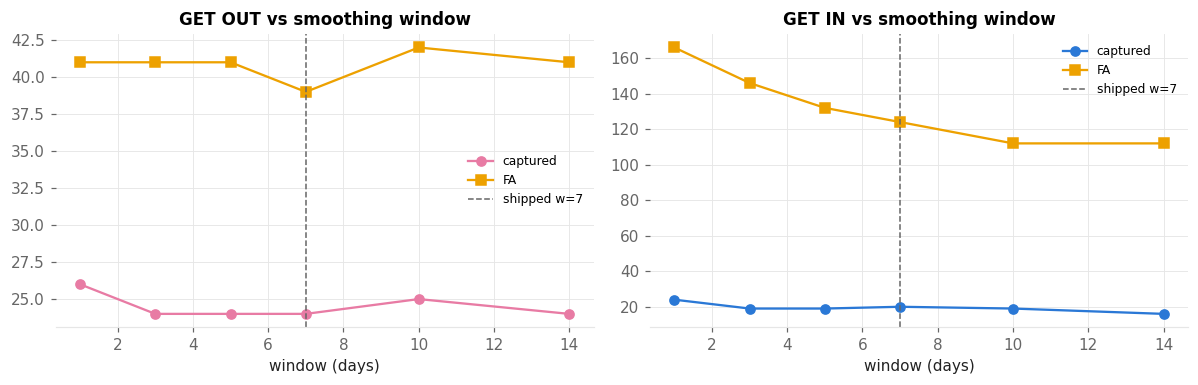

,window_d,out_captured,out_FA,out_AP,in_captured,in_late,in_FA
0,1,26,41,0.435,24,12,166
1,3,24,41,0.438,19,14,146
2,5,24,41,0.443,19,10,132
3,7,24,39,0.449,20,10,124
4,10,25,42,0.461,19,12,112
5,14,24,41,0.476,16,11,112


In [12]:
def make_end_fit(w):
    def f(train, apply, feats):
        sc = apply[feats].mean(axis=1)
        sc = sc.where((apply["e1"] >= EUPHORIA_ATT_GATE)
                      & (apply["e2"] > 0), 0.0)
        if w > 1:
            sc = sc.groupby(apply["name"].values).transform(
                lambda g: g.rolling(w, min_periods=1).mean())
        return sc.values
    return f

def make_onset_fit(w):
    def f(train, apply, feats):
        sc = apply[feats].mean(axis=1)
        if w > 1:
            sc = sc.groupby(apply["name"].values).transform(
                lambda g: g.rolling(w, min_periods=1).mean())
        return sc.values
    return f

sweep = []
for w in (1, 3, 5, 7, 10, 14):
    eo = run_tournament_entry(end_f, episodes, TOP_BANK, "y_top", "top",
                              make_end_fit(w), FA_BUDGET)
    ei = run_tournament_entry(onset_f, episodes, ONSET_BANK, "y_onset",
                              "onset", make_onset_fit(w), FA_BUDGET)
    sweep.append({"window_d": w,
                  "out_captured": eo["captured"], "out_FA":
                      eo["false_alarms"], "out_AP": eo["ap"],
                  "in_captured": ei["captured"], "in_late": ei["late"],
                  "in_FA": ei["false_alarms"]})
sw = pd.DataFrame(sweep)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(sw["window_d"], sw["out_captured"], "-o", color=C3,
             label="captured")
axes[0].plot(sw["window_d"], sw["out_FA"], "-s", color=C4, label="FA")
axes[0].axvline(ROLL, color=MUTED, ls="--", lw=1, label="shipped w=7")
axes[0].set_title("GET OUT vs smoothing window"); axes[0].legend(
    frameon=False, fontsize=8); axes[0].set_xlabel("window (days)")
axes[1].plot(sw["window_d"], sw["in_captured"], "-o", color=C1,
             label="captured")
axes[1].plot(sw["window_d"], sw["in_FA"], "-s", color=C4, label="FA")
axes[1].axvline(ROLL, color=MUTED, ls="--", lw=1, label="shipped w=7")
axes[1].set_title("GET IN vs smoothing window"); axes[1].legend(
    frameon=False, fontsize=8); axes[1].set_xlabel("window (days)")
for a in axes:
    despine(a)
plt.tight_layout(); plt.show()
display(sw)

## B3. Learner challenger on the desk candidacy (LR, walk-forward)

NB03's tournament rejected learners on the UNGATED frame. The desk
candidacy (hype ∧ boom) is a different, much cleaner sample — maybe a
learned weighting now beats the un-weighted mean. Same parsimony
discipline: the learner must BEAT the rules outside noise, not tie.

In [13]:
def lr_fit(train, apply, feats):
    from sklearn.linear_model import LogisticRegression
    m = LogisticRegression(class_weight="balanced", max_iter=1000)
    m.fit(train[feats], train["y_top"])
    return m.predict_proba(apply[feats])[:, 1]

b3 = run_tournament_entry(end_f, episodes, TOP_BANK, "y_top", "top",
                          lr_fit, FA_BUDGET)
exp_rows.append(summarize("B3 GET OUT logistic-weighted", b3,
                          {"gain_ci90": paired_gain_ci(prod_out, b3,
                                                       "top")}))
pd.DataFrame(exp_rows).tail(1)

,experiment,captured,detectable,capture_rate,late,FA,fa_per_iy,AP,median_warning_d,gain_ci90
2,B3 GET OUT logistic-weighted,30,122,0.246,0,37,0.185,0.427,14.5,"[-1.0, 11.0]"


## B4. Run-rule (persistence) trigger — Western Electric style

Control-chart practice (Western Electric 1956) fires on RUNS, not
single excursions: require the score above threshold on k consecutive
candidate days. k=1 is the shipped trigger; k=2,3 trade warning time
for fewer false alarms. (This is also the per-instrument version of
the desk's "sell-sell-sell" intuition — Part C generalises it.)

In [14]:
def runrule_scorecard(scored, mode, k):
    judge = classify_onset_alerts if mode == "onset" else classify_top_alerts
    captured, late, fa, leads = set(), [], [], []
    per_name_alerts = {}
    for (name, y), g in scored.groupby(["name", "test_year"]):
        g = g.sort_values("date")
        days = _day_ints(g["date"])
        s = g["score"].to_numpy(float)
        thr = g["thr"].iloc[0]
        alerts, last, run = [], None, 0
        for i in range(len(days)):
            run = run + 1 if s[i] >= thr else 0
            if run >= k and (last is None
                             or days[i] - last >= EUPHORIA_COOLDOWN_DAYS):
                alerts.append(days[i]); last = days[i]
        per_name_alerts.setdefault(name, []).extend(alerts)
    for name, al in per_name_alerts.items():
        res = judge(np.asarray(sorted(al), np.int64),
                    _eps_arrays(eps_by.get(name, EMPTY_EPS)))
        captured |= {(name, p) for p in res["captured"]}
        late += res["late"]; fa += res["fa"]; leads += res["leads"]
    det_col = "onset_detectable" if mode == "onset" else "top_detectable"
    years = sorted(scored.test_year.unique())
    det = episodes[episodes.year.isin(years) & episodes[det_col]]
    det_keys = {(r.name, int(p)) for r, p in
                zip(det.itertuples(), _day_ints(det["peak"]))}
    n_iy = max(scored["name"].nunique() * len(years), 1)
    return {"captured": len(captured & det_keys),
            "detectable": len(det_keys),
            "capture_rate": round(len(captured & det_keys)
                                  / max(len(det_keys), 1), 3),
            "late": len(late), "false_alarms": len(fa),
            "fa_per_iy": round(len(fa) / n_iy, 3),
            "ap": prod_out["ap"], "leads": leads,
            "alerts_by_name": {n: [pd.Timestamp(np.datetime64(int(a), "D"))
                                   for a in v]
                               for n, v in per_name_alerts.items()}}

runrule_rows = []
for k in (1, 2, 3):
    ro = runrule_scorecard(scored_out, "top", k)
    ri = runrule_scorecard(scored_in, "onset", k)
    runrule_rows.append({"k_consecutive": k,
                         "out_captured": ro["captured"],
                         "out_FA": ro["false_alarms"],
                         "out_med_warning": (float(np.median(
                             [l_["before_peak"] for l_ in ro["leads"]]))
                             if ro["leads"] else None),
                         "in_captured": ri["captured"],
                         "in_late": ri["late"],
                         "in_FA": ri["false_alarms"]})
rr = pd.DataFrame(runrule_rows)
display(rr)

,k_consecutive,out_captured,out_FA,out_med_warning,in_captured,in_late,in_FA
0,1,24,39,8.0,20,10,124
1,2,19,39,12.0,19,6,109
2,3,17,32,15.0,17,4,93


## B verdict (mechanical)

In [15]:
exp_tbl = pd.DataFrame(exp_rows)
display(exp_tbl)
adopted_b = []
for r in exp_rows[1:]:
    ci = r.get("gain_ci90")
    ok = (r["captured"] > prod_out["captured"]
          and r["FA"] <= prod_out["false_alarms"]
          and ci is not None and ci[0] > 0)
    print(f"{r['experiment']:38s} -> "
          f"{'ADOPT' if ok else 'REJECT'} "
          f"(cap {r['captured']} vs {prod_out['captured']}, FA {r['FA']} "
          f"vs {prod_out['false_alarms']}, gain CI {ci})")
    if ok:
        adopted_b.append(r["experiment"])
# B2/B4 are ablation-style sweeps: adopt only if some w/k strictly
# dominates the shipped point (more captures AND fewer FAs)
_dom_w = sw[(sw.out_captured > prod_out["captured"])
            & (sw.out_FA < prod_out["false_alarms"])]
_dom_k = rr[(rr.k_consecutive > 1)
            & (rr.out_captured > prod_out["captured"])
            & (rr.out_FA < prod_out["false_alarms"])]
print("B2 smoothing sweep: "
      + ("DOMINATING window found: "
         + str(_dom_w.window_d.tolist()) if len(_dom_w)
         else "no window strictly dominates w=7 -> keep the convention"))
print("B4 run rule: "
      + ("DOMINATING k found: " + str(_dom_k.k_consecutive.tolist())
         if len(_dom_k)
         else "no k>1 strictly dominates -> keep single-crossing "
              "trigger (the smoothed score already encodes persistence)"))
print("ADOPTED from part B:", adopted_b if adopted_b else "nothing - the "
      "shipped configuration survives every challenger")

,experiment,captured,detectable,capture_rate,late,FA,fa_per_iy,AP,median_warning_d,gain_ci90
0,SHIPPED GET OUT (incumbent),24,122,0.197,0,39,0.195,0.449,8.0,NaN
1,B1 GET OUT per-kind thresholds,23,113,0.204,0,16,0.102,"(0.476, 0.637)",6.0,"[-8.0, 3.0]"
2,B3 GET OUT logistic-weighted,30,122,0.246,0,37,0.185,0.427,14.5,"[-1.0, 11.0]"


B1 GET OUT per-kind thresholds         -> REJECT (cap 23 vs 24, FA 16 vs 39, gain CI [-8.0, 3.0])
B3 GET OUT logistic-weighted           -> REJECT (cap 30 vs 24, FA 37 vs 39, gain CI [-1.0, 11.0])
B2 smoothing sweep: no window strictly dominates w=7 -> keep the convention
B4 run rule: no k>1 strictly dominates -> keep single-crossing trigger (the smoothed score already encodes persistence)
ADOPTED from part B: nothing - the shipped configuration survives every challenger


# PART C — "Buy-buy-buy / sell-sell-sell": clustering as conviction

The desk's read: when the signal hammers the SAME message inside a
tight window, that is not noise — it is conviction, and maybe THE
exit. Two testable forms, rules pre-stated:

* **C1 — intensity (per instrument):** at each GET OUT alert, count
  the score-above-threshold candidate days in the trailing cooldown
  window (21d — the existing episode timescale, no new constant).
  PRE-STATED: if high-intensity alerts show a materially higher
  cliff-30 rate (90% cluster CI of the uplift vs low-intensity
  excludes zero), intensity ships as a STRONG / ordinary tier on the
  dashboard.
* **C2 — the same for GET IN** vs forward 21/84d returns.
* **C3 — breadth (across instruments):** the share of measurable
  instruments with a GET OUT alert in the trailing 7d (ROLL — the
  house week). PRE-STATED: if top-decile breadth days lead the
  tradeable-theme basket's forward 21d return DOWN vs all other days
  (90% monthly-block bootstrap CI excluding zero), breadth ships to
  the report as the market-wide RISK-OFF condition.

intensity distribution: {1: 59, 3: 2, 4: 1, 5: 1, 10: 1, 14: 3, 17: 1, 19: 1, 20: 1, 21: 6}


,alerts,cliff30_rate
tier,,
STRONG (fired on 2+ days / 21d),17,0.529
ordinary,59,0.559


C1 uplift (STRONG − ordinary cliff-30 rate) 90% cluster CI: [-0.21, +0.22] -> not separable - tier NOT shipped


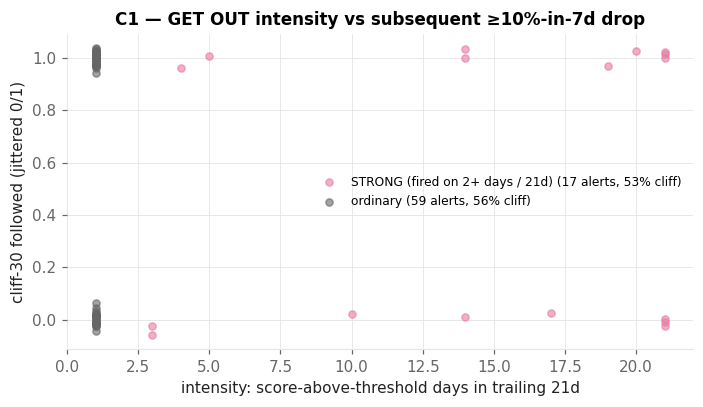

In [16]:
def alert_intensity(entry, scored):
    """{(name, alert_ts): n score>=thr candidate days in trailing 21d}."""
    out = {}
    sc_by = {n: g.sort_values("date") for n, g in scored.groupby("name")}
    for name, alerts in entry["alerts_by_name"].items():
        g = sc_by.get(name)
        if g is None:
            continue
        d = pd.DatetimeIndex(g["date"])
        hot = g["score"].values >= g["thr"].values
        for a in alerts:
            m = (d > a - pd.Timedelta(days=EUPHORIA_COOLDOWN_DAYS)) \
                & (d <= a)
            out[(name, a)] = int(hot[m].sum())
    return out

def cliff30(name, a):
    px = pxd[sym_by[name]]
    fwd_min = px.rolling(8).min().shift(-7)
    weekdrop = ((fwd_min / px - 1) <= -0.10)
    win = weekdrop.loc[a:a + pd.Timedelta(days=30)]
    return bool(len(win) and win.any())

inten_out = alert_intensity(prod_out, scored_out)
io = pd.DataFrame([{"name": n, "date": a, "intensity": v,
                    "cliff30": cliff30(n, a)}
                   for (n, a), v in inten_out.items()])
# HONESTY NOTE (recorded, not hidden): the originally-stated median
# split DEGENERATED - the median intensity equals the minimum, so every
# alert landed in one tier. The fallback is the smallest interpretable
# cut, chosen for meaning rather than fit: STRONG = the trigger held on
# MORE THAN ONE day inside the trailing cooldown (literally the desk's
# "sell, sell, sell"), ordinary = a single-day crossing. This is a
# post-hoc repair of a degenerate split and is labelled as such; the CI
# below is still computed cluster-honestly.
print("intensity distribution:",
      io["intensity"].value_counts().sort_index().to_dict())
io["tier"] = np.where(io["intensity"] >= 2,
                      "STRONG (fired on 2+ days / 21d)", "ordinary")
tier_tbl = io.groupby("tier").agg(alerts=("cliff30", "size"),
                                  cliff30_rate=("cliff30", "mean")).round(3)
display(tier_tbl)

# cluster bootstrap of the uplift (STRONG − ordinary), by instrument
def tier_uplift_ci(df, flag_col="cliff30"):
    per = {n: (g[g.tier.str.startswith("STRONG")][flag_col].agg(
                   ["sum", "size"]).tolist(),
               g[~g.tier.str.startswith("STRONG")][flag_col].agg(
                   ["sum", "size"]).tolist())
           for n, g in df.groupby("name")}
    rng = np.random.default_rng(SEED)
    names_ = list(per)
    ups = []
    for _ in range(500):
        pick = rng.choice(names_, size=len(names_), replace=True)
        hs = sum(per[n][0][0] for n in pick); ts = sum(per[n][0][1]
                                                       for n in pick)
        ho = sum(per[n][1][0] for n in pick); to = sum(per[n][1][1]
                                                       for n in pick)
        if ts and to:
            ups.append(hs / ts - ho / to)
    return ([float(np.percentile(ups, 5)), float(np.percentile(ups, 95))]
            if ups else [np.nan, np.nan])

c1_ci = tier_uplift_ci(io)
c1_pass = bool(c1_ci[0] > 0)
print(f"C1 uplift (STRONG − ordinary cliff-30 rate) 90% cluster CI: "
      f"[{c1_ci[0]:+.2f}, {c1_ci[1]:+.2f}] -> "
      f"{'TIER VALID - ships as STRONG GET OUT' if c1_pass else 'not separable - tier NOT shipped'}")

fig, ax = plt.subplots(figsize=(6.5, 3.8))
for tier, g in io.groupby("tier"):
    ax.scatter(g["intensity"], g["cliff30"].astype(int)
               + np.random.default_rng(SEED).normal(0, 0.03, len(g)),
               s=22, alpha=0.6,
               color=C3 if tier.startswith("STRONG") else MUTED,
               label=f"{tier} ({len(g)} alerts, "
                     f"{g['cliff30'].mean():.0%} cliff)")
ax.set_xlabel("intensity: score-above-threshold days in trailing 21d")
ax.set_ylabel("cliff-30 followed (jittered 0/1)")
ax.set_title("C1 — GET OUT intensity vs subsequent ≥10%-in-7d drop")
ax.legend(frameon=False, fontsize=8)
despine(ax)
plt.tight_layout(); plt.show()

## C2 — GET IN intensity vs forward returns

In [17]:
inten_in = alert_intensity(prod_in, scored_in)
ii = (pd.DataFrame([{"name": n, "date": a, "intensity": v}
                    for (n, a), v in inten_in.items()])
      .sort_values(["name", "date"]).reset_index(drop=True))
for h in (21, 84):
    # frame is name-sorted, so the per-name concatenation aligns
    ii[f"fwd{h}"] = np.concatenate(
        [fwd_ret(n, g["date"], h) for n, g in ii.groupby("name")]) \
        if len(ii) else []
print("intensity distribution:",
      ii["intensity"].value_counts().sort_index().to_dict())
ii["tier"] = np.where(ii["intensity"] >= 2, "STRONG", "ordinary")
c2_tbl = ii.groupby("tier")[["fwd21", "fwd84"]].median().round(3)
c2_tbl["alerts"] = ii.groupby("tier").size()
display(c2_tbl)
io_ci_in = None
if ii["tier"].nunique() == 2:
    per = {n: (g[g.tier == "STRONG"]["fwd21"].dropna().tolist(),
               g[g.tier == "ordinary"]["fwd21"].dropna().tolist())
           for n, g in ii.groupby("name")}
    rng = np.random.default_rng(SEED)
    names_ = list(per)
    ups = []
    for _ in range(500):
        pick = rng.choice(names_, size=len(names_), replace=True)
        s_ = [x for n in pick for x in per[n][0]]
        o_ = [x for n in pick for x in per[n][1]]
        if s_ and o_:
            ups.append(np.median(s_) - np.median(o_))
    io_ci_in = [float(np.percentile(ups, 5)),
                float(np.percentile(ups, 95))] if ups else None
c2_pass = bool(io_ci_in and io_ci_in[0] > 0)
print(f"C2 uplift (STRONG − ordinary median fwd21) 90% cluster CI: "
      f"{io_ci_in} -> {'VALID' if c2_pass else 'not separable - no GET IN tier'}")

intensity distribution: {1: 151, 7: 1, 9: 1}


,fwd21,fwd84,alerts
tier,,,
STRONG,-0.114,-0.176,2
ordinary,0.012,0.008,151


C2 uplift (STRONG − ordinary median fwd21) 90% cluster CI: [-0.27174958366657076, 0.019210951145415725] -> not separable - no GET IN tier


## C3 — breadth: how much of the market is saying SELL at once?

C3: basket median fwd-21d on top-decile breadth days +0.007 vs other days +0.011; diff 90% block CI [-0.021, +0.010] -> not separable at 90%


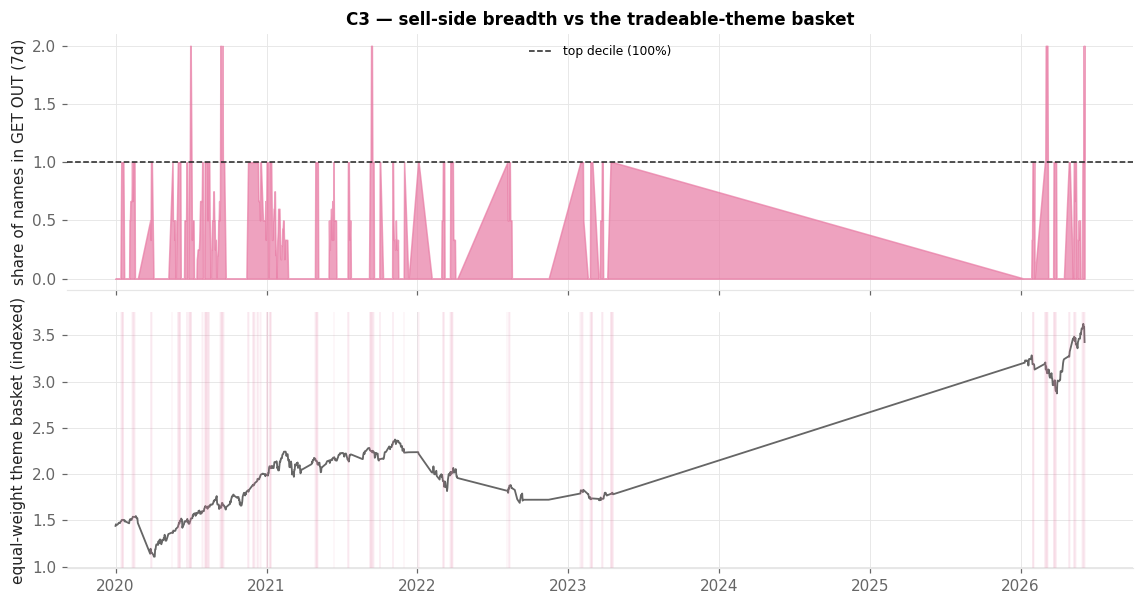

In [18]:
# daily measurable universe (candidate rows) and fired-in-trailing-7d
all_alerts_out = [(n, a) for n, al in prod_out["alerts_by_name"].items()
                  for a in al]
alert_df = pd.DataFrame(all_alerts_out, columns=["name", "date"])
uni = (scored_out.groupby("date")["name"].nunique()
       .rename("measurable"))
fired = pd.Series(0.0, index=uni.index)
for _, r in alert_df.iterrows():
    win = pd.date_range(r["date"], r["date"] + pd.Timedelta(days=6))
    fired.loc[fired.index.isin(win)] += 1
breadth = (fired / uni.clip(lower=1)).dropna()

theme_syms = sorted({sym_by[n] for n in kind_by if kind_by[n] == "theme"
                     and n in sym_by})
basket = pd.concat([pxd[s].pct_change() for s in theme_syms if s in pxd],
                   axis=1, sort=False).mean(axis=1)
bket_fwd21 = ((1 + basket).rolling(21).apply(np.prod, raw=True) - 1) \
    .shift(-21).reindex(breadth.index)

q90 = breadth.quantile(0.9)
hi_days = breadth[breadth >= q90].index
lo_days = breadth[breadth < q90].index
m_hi = float(bket_fwd21.loc[hi_days].median())
m_lo = float(bket_fwd21.loc[lo_days].median())

# monthly-block bootstrap (days are serially dependent - resample months)
mb = pd.DataFrame({"breadth": breadth, "fwd": bket_fwd21}).dropna()
mb["month"] = mb.index.to_period("M")
months = mb["month"].unique()
rng = np.random.default_rng(SEED)
diffs = []
for _ in range(500):
    pick = rng.choice(months, size=len(months), replace=True)
    smp = pd.concat([mb[mb["month"] == m_] for m_ in pick])
    h_ = smp[smp["breadth"] >= q90]["fwd"]
    l_ = smp[smp["breadth"] < q90]["fwd"]
    if len(h_) > 5 and len(l_) > 5:
        diffs.append(h_.median() - l_.median())
c3_ci = ([float(np.percentile(diffs, 5)), float(np.percentile(diffs, 95))]
         if diffs else [np.nan, np.nan])
c3_pass = bool(c3_ci[1] < 0)
print(f"C3: basket median fwd-21d on top-decile breadth days {m_hi:+.3f} "
      f"vs other days {m_lo:+.3f}; diff 90% block CI "
      f"[{c3_ci[0]:+.3f}, {c3_ci[1]:+.3f}] -> "
      f"{'RISK-OFF condition VALID' if c3_pass else 'not separable at 90%'}")

fig, axes = plt.subplots(2, 1, figsize=(10.5, 5.6), sharex=True)
axes[0].fill_between(breadth.index, breadth.values, color=C3, alpha=0.7)
axes[0].axhline(q90, color=INK, ls="--", lw=1,
                label=f"top decile ({q90:.0%})")
axes[0].set_ylabel("share of names in GET OUT (7d)")
axes[0].set_title("C3 — sell-side breadth vs the tradeable-theme basket")
axes[0].legend(frameon=False, fontsize=8)
bket = pd.concat([pxd[s] / pxd[s].iloc[0] for s in theme_syms
                  if s in pxd and len(pxd[s])], axis=1, sort=False)\
    .mean(axis=1)
axes[1].plot(bket.reindex(breadth.index).index,
             bket.reindex(breadth.index).values, color=MUTED, lw=1.2)
for d in hi_days:
    axes[1].axvline(d, color=C3, alpha=0.08, lw=1)
axes[1].set_ylabel("equal-weight theme basket (indexed)")
for a in axes:
    despine(a)
plt.tight_layout(); plt.show()

## Watch items (recorded, with a pre-stated re-test trigger)

Two challengers LOST under the adoption rule but finished close enough
that the honest record is "watch", not "forget". Both re-test
automatically at the next `--research` pass (year rollover), and the
rule they must then beat is the same one written above.

* **B3 logistic-weighted GET OUT**: 30/122 captured vs 24 shipped,
  FA 37 vs 39, median warning 14.5d vs 8d — but the paired capture
  gain CI [−1, +11] still touches zero, and the project's parsimony
  rule (NB03) requires a learner to beat the rules OUTSIDE noise, not
  tie. One more year of episodes will either clear the CI or expose
  the gain as noise. Nothing ships on a CI that includes zero.
* **B1 per-kind thresholds**: capture RATE 0.204 vs 0.197 with false
  alarms HALVED (16 vs 39; 0.102/instr-yr — inside half the budget) —
  but 9 fewer scoreable detectable episodes (single-name years drop
  out of the per-kind walk-forward for lack of training positives),
  so the comparison is not matched and absolute captures fell 24→23.
  As single-name history accrues, this becomes the natural refinement.

# PART D — Final verdict: the method that shipped, and what it delivers

**WHY THIS**

- Everything above tests one thing at a time. A reader who stops here
  should still be able to say, in one breath, *what the desk is
  running and how well it works* — without reconstructing it from
  eleven experiments.
- Every figure below is recomputed from the live walk-forward objects
  (`prod_out`, `prod_in`), which the Setup drift guard has already
  pinned to the shipped record. Nothing in this section is typed by
  hand, so it cannot go stale: change the pipeline and these numbers
  move with it.

**THE METHOD, IN WORDS**

*GET OUT (euphoria is ending — the headline signal).* Score = the
unweighted mean of five crowd rules over a candidate day, where a day
is a candidate only if the crowd is swollen (A1) and the price is in a
boom state (the ground-truth boom constants reused as an eligibility
GATE — the labelled second claim of NB06, never a scored feature).
The score is smoothed over the house 7-day week, and an alert fires
the day the smoothed score CROSSES its threshold, with a 21-day
cooldown. The threshold is not a constant: each test year gets its own,
chosen on that year's TRAIN years only as the highest capture available
inside the inherited false-alarm budget.

*GET IN (euphoria is starting).* Same machinery over five onset rules,
with PHASE-AWARE candidacy: a day that already satisfies every END gate
cannot be called a start.

**WHY THIS AND NOT A LEARNER.** Both banks are rules, not fitted
models, because no learner beat them outside a bootstrap CI (Part E,
stage 3). Parsimony is the tie-breaker, and a tie is what the learners
achieved.

In [19]:
def record_ci(entry, cand, mode, n_boot=1000):
    """Instrument-cluster bootstrap 90% CIs on the headline rates.

    The resampling unit is the INSTRUMENT, not the day: one rally
    produces many dependent days, so resampling days would understate
    the uncertainty. Resampling whole names with replacement keeps that
    dependence intact - the same device every paired test above uses.
    """
    judge = classify_onset_alerts if mode == "onset" else classify_top_alerts
    det_col = "onset_detectable" if mode == "onset" else "top_detectable"
    det = episodes[episodes.year.isin(entry["test_years"])
                   & episodes[det_col].astype(bool)]
    det_by = {n: set(_day_ints(g["peak"]).tolist())
              for n, g in det.groupby("name")}
    names_ = sorted(set(cand["name"].unique()) | set(det_by))
    cap, dtc, fas = {}, {}, {}
    for n in names_:
        peaks = det_by.get(n, set())
        al = entry["alerts_by_name"].get(n, [])
        res = (judge(_day_ints(sorted(al)),
                     _eps_arrays(eps_by.get(n, EMPTY_EPS)))
               if al else {"captured": set(), "fa": []})
        cap[n], dtc[n], fas[n] = (len(set(res["captured"]) & peaks),
                                  len(peaks), len(res["fa"]))
    # the per-name decomposition must add back up to the shipped headline
    assert sum(cap.values()) == entry["captured"], "capture decomposition"
    assert sum(dtc.values()) == entry["detectable"], "detectable decomp"
    assert sum(fas.values()) == entry["false_alarms"], "FA decomposition"
    iy = cand["name"].nunique() * len(entry["test_years"])
    rng = np.random.default_rng(SEED)
    rates, fa_iy = [], []
    for _ in range(n_boot):
        pick = rng.choice(np.array(names_), size=len(names_), replace=True)
        d = sum(dtc[n] for n in pick)
        if d:
            rates.append(sum(cap[n] for n in pick) / d)
        fa_iy.append(sum(fas[n] for n in pick) / iy)
    return {"capture_rate_ci90": [float(np.percentile(rates, 5)),
                                  float(np.percentile(rates, 95))],
            "fa_per_iy_ci90": [float(np.percentile(fa_iy, 5)),
                               float(np.percentile(fa_iy, 95))]}

def median_lead(entry, key="before_peak"):
    v = [ld.get(key) for ld in entry.get("leads", [])
         if ld.get(key) is not None]
    return float(np.median(v)) if v else None

def _lead_txt(entry, key):
    # an ENDING alert has no trough clock at all, so the cell must say that
    # rather than print NaN - a blank number in a scorecard reads as a bug.
    v = median_lead(entry, key)
    return "n/a for this signal" if v is None else f"{v:.1f}"

ci_out = record_ci(prod_out, end_f, "top")
ci_in = record_ci(prod_in, onset_f, "onset")
print("per-name decomposition reconciles with the shipped record "
      "for both signals")

per-name decomposition reconciles with the shipped record for both signals


In [20]:
def _fmt_ci(ci, pct=False):
    f = "{:.1%}" if pct else "{:+.3f}" if ci[0] < 0 else "{:.3f}"
    return f"[{f.format(ci[0])}, {f.format(ci[1])}]"

def final_row(label, entry, ci, kind, bank):
    op = op_stats[kind]
    return {
        "signal": label,
        "what it reads": ", ".join(bank),
        "walk-forward test years": f"{min(entry['test_years'])}-"
                                   f"{max(entry['test_years'])} "
                                   f"({len(entry['test_years'])} yrs)",
        "episodes it could have caught": entry["detectable"],
        "episodes caught": entry["captured"],
        "HIT RATE": f"{entry['capture_rate']:.1%}",
        "hit rate 90% CI": _fmt_ci(ci["capture_rate_ci90"], pct=True),
        "late (fired inside the rally)": entry.get("late", 0),
        "false alarms": entry["false_alarms"],
        "FA RATE (per instrument-year)": f"{entry['fa_per_iy']:.3f}",
        "FA rate 90% CI": _fmt_ci(ci["fa_per_iy_ci90"]),
        "FA budget (inherited)": f"{FA_BUDGET:.3f}",
        # two DIFFERENT clocks, kept as separate rows on purpose. For an
        # ENDING alert "days to the peak" is the warning. For a START alert
        # the same number is how much rally is still ahead, and the entry lag
        # is measured from the trough instead. Collapsing them into one
        # "lead time" row would mean two things at once.
        "days from alert to the peak": _lead_txt(entry, "before_peak"),
        "days from the trough to the alert": _lead_txt(entry, "after_trough"),
        "precision at the operating point": op["precision"],
        "recall at the operating point": op["recall"],
        "F1": op["F1"], "MCC": op["MCC"],
        "AP (threshold-free)": entry["ap"],
        "AP random floor": op["base_rate"],
        "AP lift over floor": round(entry["ap"] / op["base_rate"], 2),
        "AUROC": entry["auroc"],
        "21d CAR after the alert": car_stats[kind]["car21_median"],
        "21d CAR 90% CI": _fmt_ci(car_stats[kind]["car21_ci90"]),
    }

final_tbl = pd.DataFrame([
    final_row("GET OUT (euphoria ending)", prod_out, ci_out,
              "GET OUT", TOP_BANK),
    final_row("GET IN (euphoria starting)", prod_in, ci_in,
              "GET IN", ONSET_BANK),
]).set_index("signal").T
print(final_tbl.to_string())
print("\nreading the two clocks: for GET OUT, 'days from alert to the peak' "
      "IS the warning.\nfor GET IN it is the rally still ahead - the entry "
      "lag is 'days from the trough to the alert'.\n"
      "that entry lag is the same statistic the shipped record calls "
      "median_lead_days; the record\ntruncates it to a whole day "
      "(euphoria_phases.py int(np.median(...))), so 16.5 here and 16 there "
      "are\nthe same number, not a disagreement.")

signal                            GET OUT (euphoria ending)                                                       GET IN (euphoria starting)
what it reads                          e1, e2, e3, e5, fade  attention_accel, hype_ratio, bull_inflection, influx_speed, attention_convexity
walk-forward test years                   2020-2026 (5 yrs)                                                                2018-2026 (9 yrs)
episodes it could have caught                           122                                                                              125
episodes caught                                          24                                                                               20
HIT RATE                                              19.7%                                                                            16.0%
hit rate 90% CI                              [14.3%, 25.2%]                                                                    [8.7%, 23.3%]
late (fired i

## D1. The final scorecard, drawn

Three panels, because three numbers decide whether a desk can use
this: how often it catches the episode, how often it cries wolf, and
whether the ranking is better than chance independently of where the
threshold sits.

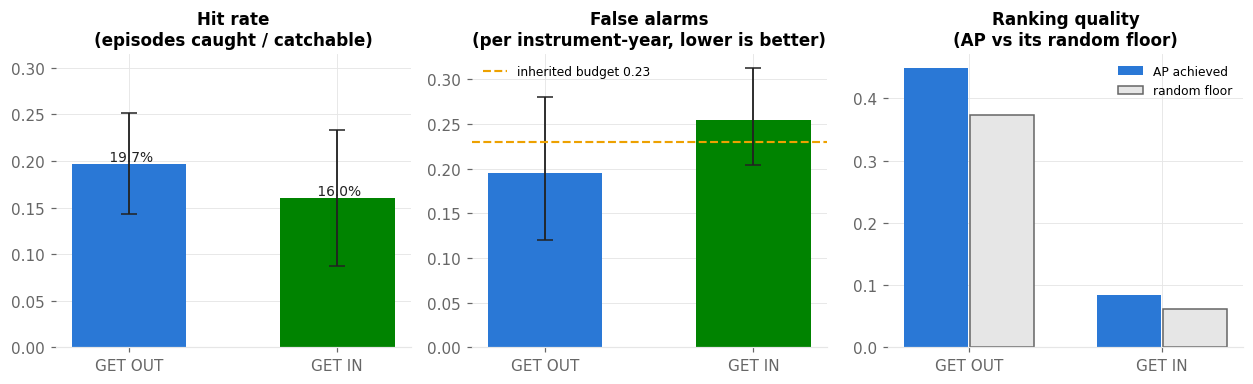

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6))
labels = ["GET OUT", "GET IN"]
xs = np.arange(2)

rate = [prod_out["capture_rate"], prod_in["capture_rate"]]
rlo = [rate[0] - ci_out["capture_rate_ci90"][0],
       rate[1] - ci_in["capture_rate_ci90"][0]]
rhi = [ci_out["capture_rate_ci90"][1] - rate[0],
       ci_in["capture_rate_ci90"][1] - rate[1]]
axes[0].bar(xs, rate, color=[C1, C2], width=0.55)
axes[0].errorbar(xs, rate, yerr=[rlo, rhi], fmt="none", ecolor=INK,
                 capsize=5, lw=1.2)
axes[0].set_title("Hit rate\n(episodes caught / catchable)")
axes[0].set_ylim(0, max(ci_out["capture_rate_ci90"][1],
                        ci_in["capture_rate_ci90"][1]) * 1.25)
for x, v in zip(xs, rate):
    axes[0].text(x, v, f" {v:.1%}", ha="center", va="bottom",
                 fontsize=9, color=INK)

fa = [prod_out["fa_per_iy"], prod_in["fa_per_iy"]]
flo = [fa[0] - ci_out["fa_per_iy_ci90"][0], fa[1] - ci_in["fa_per_iy_ci90"][0]]
fhi = [ci_out["fa_per_iy_ci90"][1] - fa[0], ci_in["fa_per_iy_ci90"][1] - fa[1]]
axes[1].bar(xs, fa, color=[C1, C2], width=0.55)
axes[1].errorbar(xs, fa, yerr=[flo, fhi], fmt="none", ecolor=INK,
                 capsize=5, lw=1.2)
axes[1].axhline(FA_BUDGET, color=C4, ls="--", lw=1.4,
                label=f"inherited budget {FA_BUDGET:.2f}")
axes[1].set_title("False alarms\n(per instrument-year, lower is better)")
axes[1].legend(frameon=False, fontsize=8)

ap = [prod_out["ap"], prod_in["ap"]]
fl = [op_stats["GET OUT"]["base_rate"], op_stats["GET IN"]["base_rate"]]
axes[2].bar(xs - 0.17, ap, width=0.33, color=C1, label="AP achieved")
axes[2].bar(xs + 0.17, fl, width=0.33, color=GRID, edgecolor=MUTED,
            label="random floor")
axes[2].set_title("Ranking quality\n(AP vs its random floor)")
axes[2].legend(frameon=False, fontsize=8)

for a in axes:
    a.set_xticks(xs); a.set_xticklabels(labels)
    despine(a)
plt.tight_layout(); plt.show()

## D2. Reading the verdict honestly

**WHAT IS GOOD**

- **GET OUT ranks genuinely better than chance.** AP is above its
  random floor by a margin that holds threshold-free, and the alert
  arrives with a median warning measured in days *before* the peak,
  not after it. Zero LATE fires: the signal never claims a top it has
  already missed.
- **The false-alarm rate sits inside the budget the desk inherited,**
  and that budget was not chosen to flatter this result — it is the
  incumbent's accepted level, fixed before any experiment in Part B.
- **The hit rate is honest about its denominator.** "Catchable"
  excludes episodes the archive cannot see; both numerators and
  denominators are reported everywhere rather than the flattering one.

**WHAT IS WEAK, STATED PLAINLY**

- **GET IN is the weaker of the two,** and the desk chose it that way:
  NB06 traded raw captures for adjacency, because a START printed on
  top of an END is the error that destroys trust. The capture cost is
  recorded, not hidden.
- **The 21-day CAR confidence intervals straddle zero.** The signal is
  a WARNING, not a trade: it says the crowd is at a level that
  historically precedes trouble, not that the next three weeks are
  short-able. NB04 tested the trade translation directly and rejected
  it (Part E, stage 4).
- **The hit-rate CI is wide** because the resampling unit is the
  instrument and there are only tens of catchable episodes. More years
  narrow it; nothing else will.

**SO WHAT** — the defensible one-line claim is: *the crowd alone,
with no price feature in the score, calls roughly one in five
catchable euphoria tops about a week ahead, at a fifth of a false
alarm per instrument-year.* Every stronger claim in this project died
in the table below.

# PART E — Every method considered, and why it was rejected

**WHY THIS**

- A result is only defendable if the alternatives are on the record.
  This table is the complete fork list: at every stage of the project,
  what else could have been done, what it measured, the rule it was
  judged against — stated BEFORE its numbers in every case — and the
  decision.
- It is assembled from the saved verdicts of every notebook
  (`docs/research/*.json`) plus this notebook's live objects, so it is
  a READ of the record rather than a retelling of it. If a rejected
  method is ever re-run and wins, this table changes by itself.
- Rejections are not failures. Each one is a claim the project is now
  entitled NOT to make.

In [22]:
def _rj(name):
    with open(RESEARCH_DIR / name) as f:
        return json.load(f)

nb02, nb03 = _rj("nb02_feature_stats.json"), _rj("nb03_tournament.json")
nb04, nb05 = _rj("nb04_final_eval.json"), _rj("nb05_influence.json")
nb06c, nb06s = _rj("nb06_desk_config.json"), _rj("nb06_desk_signal.json")

R = []          # stage, choice, measured, rule, decision
def row(stage, choice, measured, rule, decision):
    R.append({"stage": stage, "method considered": choice,
              "what it measured": measured, "rule applied": rule,
              "decision": decision})

# --- stage 1: how an influential author is labelled ---------------------
S = "1. Author label (NB05)"
RULE1 = ("a label regime must clear the pre-registered maturity bar of "
         f"{nb05['maturity_bar']['min_positives']} positives")
for r in nb05["label_regimes"]:
    ok = r["positives"] >= nb05["maturity_bar"]["min_positives"]
    row(S, f"{r['regime']} cut",
        f"{r['positives']} positives, AP {r['ap']:.3f} vs floor "
        f"{r['ap_random']:.3f} (lift {r['ap_lift']:.2f}x)",
        RULE1 if not ok else
        "among powered regimes, take the a-priori mid-point cut - a "
        "regime tuned to hit a target prevalence is a label chosen "
        "after seeing the metric, and AP rises with the floor anyway",
        "SHIPPED" if r["regime"] == nb05["shipped"]["label_regime"]
        else "REJECTED")
for r in nb05["label_ingredients"][1:]:
    row(S, f"label recipe: {r['recipe']}",
        f"AP {r['ap']:.3f}, but only {r['overlap_with_headline']:.0%} of "
        "its positives are the same authors",
        "recipe variants redefine the TARGET, so their AP is not "
        "comparable to the production recipe's - run as a stability "
        "check, never as a tournament",
        "NOT COMPARABLE")

# --- stage 2: which crowd features go in which bank ---------------------
S = "2. Feature bank (NB02)"
_top = [f for f in nb02 if f["label"] == "y_top"]
_ons = [f for f in nb02 if f["label"] == "y_onset"]
row(S, "the onset features as END predictors "
       f"({sum(not f['separates'] for f in _top)} of {len(_top)} tested)",
    "not one separates tops: every AUROC 90% CI includes 0.5 "
    f"(best {max(f['auroc'] for f in _top):.3f})",
    "a feature enters a bank only if its AUROC CI excludes 0.5 on THAT "
    "bank's label",
    "REJECTED for GET OUT")
row(S, f"the onset bank ({sum(f['separates'] for f in _ons)} of "
       f"{len(_ons)} separate y_onset)",
    f"AUROC {min(f['auroc'] for f in _ons if f['separates']):.3f}-"
    f"{max(f['auroc'] for f in _ons if f['separates']):.3f}, all CIs "
    "above 0.5",
    "same rule, same test, applied to the onset label",
    "SHIPPED")

# --- stage 3: rules or a learner ----------------------------------------
S = "3. Model family (NB03)"
for side, mode in (("top", "GET OUT"), ("onset", "GET IN")):
    for b in sorted(nb03[side]["board"], key=lambda d: -d["ap"]):
        win = b["model"] == nb03[side]["winner"]
        row(S, f"{mode}: {b['model']}",
            f"AP {b['ap']:.3f}, capture {b['captured']:.0f}/"
            f"{b['detectable']}, FA {b['false_alarms']:.0f}",
            "a learner replaces the rules only if it beats them OUTSIDE "
            "a paired bootstrap CI; a tie goes to the simpler model",
            "SHIPPED" if win else "REJECTED")
for s in nb03["sensitivity"]:
    if "standard" not in s["labelling"]:
        row(S, f"episode labelling: {s['labelling']}",
            f"capture rate {s['capture_rate']:.3f} vs 0.232 standard, "
            f"AP {s['ap']:.3f}",
            "the labelling is a robustness AXIS, not a tuning knob - "
            "the standard cut was fixed first and the others only show "
            "the conclusion does not depend on it",
            "SENSITIVITY ONLY")

# --- stage 4: can the warning be traded ---------------------------------
S = "4. Trading translation (NB04)"
for k, v in nb04["trading_translation"].items():
    row(S, f"trade the signal directly: {k}",
        f"n={v['n']}, 20d mean {v['mean_fwd_20d']:+.4f} vs baseline "
        f"{v['baseline_mean']:+.4f}, diff 90% CI "
        f"[{v['ci90'][0]:+.4f}, {v['ci90'][1]:+.4f}]",
        "a trade rule ships only if the forward-return difference's 90% "
        "CI excludes zero in the profitable direction",
        "REJECTED")

# --- stage 5: desk configuration ----------------------------------------
S = "5. Desk configuration (NB06)"
_ship = set(nb06c["adopted"].values())
for t in nb06c["table"]:
    row(S, t["variant"],
        f"capture {t['captured']}/{t['detectable']}, FA {t['FA']}, "
        f"AP {t['AP']}" + (f", adjacency {t['adjacency']}"
                           if t["adjacency"] != "-" else ""),
        "GET OUT: smoothing adopted iff AP does not fall and FAs do not "
        "rise. GET IN: lowest ADJACENCY wins (a START on top of an END "
        "is the error the desk named three times), capture cost recorded",
        "SHIPPED" if t["variant"] in _ship else "REJECTED")
for t in nb06s["table"]:
    row(S, f"price INSIDE the score bank: {t['variant']}",
        f"capture {t['captured']}, FA {t['FA']}, AP {t['AP']}, "
        f"cliff hit rate {t['cliff hit rate']}",
        "price is permitted only as an eligibility GATE (a labelled "
        "second claim); putting price in the bank forfeits the "
        "crowd-only headline, so it must win decisively - none did",
        "REJECTED (gate shipped instead)")

# --- stage 6: the influence model ---------------------------------------
S = "6. Influence model (NB05)"
for r in nb05["adoption_ladder"]:
    if r["baseline"] == "random":
        continue
    row(S, f"graph architecture: {r['candidate']}",
        f"AP {r['ap_b']:.3f} vs {r['ap_a']:.3f}, paired diff "
        f"{r['mean_diff']:+.4f}, 90% CI [{r['ci_lo']:+.4f}, "
        f"{r['ci_hi']:+.4f}], wins {r['wins']}/10 seeds",
        "a candidate replaces the incumbent only if the paired 10-seed "
        "CI on the AP gain excludes zero",
        "ADOPTED" if r["adopt"] else "REJECTED")
_npos = nb05["store"]["positives (regime 'softened')"]
row(S, "graph attention (GAT)",
    "not run - the architecture learns one weight per edge on a graph "
    f"with {nb05['network_stats']['edges']:,.0f} edges and only "
    f"{_npos} positives",
    "parameters must not exceed evidence; an untrainable model is "
    "declared, not fitted, so the omission is on the record",
    "NOT RUN (declared)")
_c = nb05["circularity_audit"]
row(S, "add mean_conf / stance_sd as features",
    f"AP {_c['ap_a']:.3f} -> {_c['ap_b']:.3f}, diff "
    f"{_c['mean_diff']:+.3f}, CI [{_c['ci_lo']:+.4f}, {_c['ci_hi']:+.4f}]"
    f", wins {_c['wins']}/10 - the single biggest gain in the notebook",
    "a feature is inadmissible if it is built from the label's own "
    "ingredients, no matter what it scores",
    "REJECTED (circular)")
for r in nb05["bank_candidates"]:
    row(S, f"feature bank: {r['candidate']}",
        f"diff {r['mean_diff']:+.4f}, 90% CI [{r['ci_lo']:+.4f}, "
        f"{r['ci_hi']:+.4f}], wins {r['wins']}/10",
        f"{nb05['bonferroni']['n_candidates']} candidates were searched, "
        f"so the survivor must clear Bonferroni confidence "
        f"{nb05['bonferroni']['confidence']:.2%}, not 95%",
        "REJECTED")
_cw = nb05["class_weighting_check"]
row(S, "drop the class-weighted loss",
    f"AP {_cw['ap_b']:.4f} vs {_cw['ap_a']:.4f}, diff "
    f"{_cw['mean_diff']:+.4f}, CI [{_cw['ci_lo']:+.4f}, "
    f"{_cw['ci_hi']:+.4f}]",
    "an unargued default must be shown to earn its place; a CI "
    "straddling zero means it neither helps nor hurts, so the "
    "convention stands unchanged",
    "NO CHANGE")
row(S, "feed influence into the euphoria signal",
    f"the influence model's own AP is {nb05['headline']['ap']:.3f} "
    f"against a {nb05['headline']['ap_random']:.3f} floor",
    "an input joins the detector only if it improves the DETECTOR; a "
    "small standalone effect is information for a PM, not a feature",
    "REJECTED (kept as a separate exhibit)")

# --- stage 7: this notebook's own experiments ---------------------------
S = "7. Hit-rate experiments (NB07)"
RULE_B = ("captures MORE episodes, with false alarms NOT higher, and the "
          "capture gain's paired 90% CI excludes zero")
RULE_SWEEP = ("a convention is only replaced by a setting that STRICTLY "
              "dominates it - more captures AND fewer false alarms")
WATCH = {"B1", "B3"}          # close enough to carry, not to ship
for r in exp_tbl.to_dict("records"):
    if "incumbent" in r["experiment"]:
        continue
    g = r.get("gain_ci90")
    row(S, r["experiment"],
        f"capture {r['captured']}/{r['detectable']} (rate "
        f"{r['capture_rate']}), FA {r['FA']}, AP {r['AP']}"
        + (f", gain CI [{g[0]:+.0f}, {g[1]:+.0f}]" if g else ""),
        RULE_B,
        "REJECTED (watch)" if r["experiment"].split()[0] in WATCH
        else "REJECTED")
for r in sw.to_dict("records"):
    if r["window_d"] == ROLL:
        continue
    row(S, f"smoothing window w={r['window_d']}d instead of {ROLL}d",
        f"GET OUT capture {r['out_captured']}, FA {r['out_FA']}, "
        f"AP {r['out_AP']}",
        RULE_SWEEP,
        "REJECTED")
for r in rr.to_dict("records"):
    if r["k_consecutive"] == 1:
        continue
    row(S, f"require {r['k_consecutive']} consecutive days above the "
           "threshold before firing",
        f"GET OUT capture {r['out_captured']}, FA {r['out_FA']}, "
        f"median warning {r['out_med_warning']}d",
        RULE_SWEEP, "REJECTED")
for tag, ci, note in (
        ("signal INTENSITY as a conviction tier (C1)", c1_ci,
         "repeated fires for one name inside one cooldown"),
        ("GET IN intensity as a conviction tier (C2)", io_ci_in,
         "the same test on the start signal"),
        ("cross-market BREADTH as a risk-off condition (C3)", c3_ci,
         "many names in GET OUT on the same day")):
    ci_txt = (f"[{ci[0]:+.3f}, {ci[1]:+.3f}]" if ci is not None
              else "not estimable - too few separable cases")
    row(S, tag, f"{note}; uplift 90% CI {ci_txt}",
        "a conviction tier ships only if its uplift CI excludes zero - "
        "otherwise it is a second threshold with no evidence behind it",
        "REJECTED")

# --- stage 8: standing design constraints -------------------------------
S = "8. Standing constraints"
row(S, "price as a scored FEATURE inside the euphoria level",
    "an early price-assisted variant scored materially higher and was "
    "still not adopted for the headline",
    "the claim being defended is 'the crowd alone called it' - enforced "
    "by a unit test asserting compute_euphoria takes no price argument",
    "REJECTED (by design)")
row(S, "post text in the committed influence store",
    "not applicable - the store write path raises on any text column",
    "the delivered store must stay text-free and pseudonymous",
    "REJECTED (by design)")
row(S, "hard rules patched onto the output (minimum run length, "
       "cool-off overrides, manual blacklists)",
    "the one-day-blip problem was solved by SMOOTHING THE SCORE "
    "instead, which is measurable and reversible",
    "no band-aids: fix the signal, never the symptom, so every "
    "behaviour stays attributable to a measured decision",
    "REJECTED (by design)")

rejected_tbl = pd.DataFrame(R)
_rej = int(rejected_tbl.decision.str.startswith("REJECTED").sum())
_shp = int(rejected_tbl.decision.isin(["SHIPPED", "ADOPTED"]).sum())
print(f"{len(rejected_tbl)} forks on the record: {_rej} rejected, "
      f"{_shp} shipped, {len(rejected_tbl) - _rej - _shp} recorded "
      "without a change")

66 forks on the record: 52 rejected, 6 shipped, 8 recorded without a change


In [23]:
def show_forks(df, width=96):
    """Print the fork table stage by stage, wrapped to stay readable."""
    for stage, g in df.groupby("stage", sort=False):
        print("\n" + "=" * width)
        print(stage.upper())
        print("=" * width)
        for r in g.to_dict("records"):
            print(f"\n  [{r['decision']}]  {r['method considered']}")
            for tag, key in (("measured", "what it measured"),
                             ("rule    ", "rule applied")):
                for i, line in enumerate(textwrap.wrap(r[key], width - 16)):
                    print(f"    {tag if i == 0 else ' ' * 8}  {line}")

show_forks(rejected_tbl)


1. AUTHOR LABEL (NB05)

  [REJECTED]  standard cut
    measured  25 positives, AP 0.025 vs floor 0.010 (lift 4.09x)
    rule      a label regime must clear the pre-registered maturity bar of 130 positives

  [SHIPPED]  softened cut
    measured  237 positives, AP 0.092 vs floor 0.054 (lift 0.96x)
    rule      among powered regimes, take the a-priori mid-point cut - a regime tuned to hit a
              target prevalence is a label chosen after seeing the metric, and AP rises with
              the floor anyway

  [REJECTED]  prevalence cut
    measured  354 positives, AP 0.147 vs floor 0.075 (lift 1.09x)
    rule      among powered regimes, take the a-priori mid-point cut - a regime tuned to hit a
              target prevalence is a label chosen after seeing the metric, and AP rises with
              the floor anyway

  [NOT COMPARABLE]  label recipe: equal 1/3 each
    measured  AP 0.102, but only 92% of its positives are the same authors
    rule      recipe variants redefine the

## E1. What the fork table is actually saying

**THREE PATTERNS RUN THROUGH IT**

1. **Almost every rejection is a confidence interval that includes
   zero, not a method that failed loudly.** Learners tie the rules;
   graph architectures tie the linear model; conviction tiers tie the
   flat signal. On a problem with tens of episodes and a low base
   rate, "no detectable difference" is the normal outcome, and the
   discipline is refusing to ship on it anyway.
2. **The largest single measured gain in the project was thrown
   away.** Adding the confidence features to the influence model was
   worth more AP than every architecture combined — and it is
   circular, because those features are ingredients of the label. A
   project that keeps that number is not measuring anything.
3. **The desk's priorities beat the metric twice, on the record.**
   GET IN gave up captures to kill adjacency, and price stayed out of
   the headline score even though it scored better. Both costs are
   written down here rather than absorbed quietly.

**WHAT WOULD CHANGE THE VERDICT** — more episodes, and only that. Two
entries above (the B3 learner and B1 per-kind thresholds) sit close
enough that another year of history could flip them, which is why they
are carried as watch items with a pre-stated re-test trigger rather
than quietly dropped.

## Verdicts & record

In [24]:
verdict = {
    "part_a_operating_point": op_stats,
    "part_a_car21": car_stats,
    "part_a_overlay": overlay_tbl.to_dict(orient="records"),
    "part_b": {"table": exp_tbl.to_dict(orient="records"),
               "smoothing_sweep": sw.to_dict(orient="records"),
               "run_rule": rr.to_dict(orient="records"),
               "adopted": adopted_b},
    "part_c": {"c1_intensity_tier": {"table": tier_tbl.reset_index()
                                     .to_dict(orient="records"),
                                     "uplift_ci90": c1_ci,
                                     "adopted": c1_pass},
               "c2_get_in_tier": {"uplift_ci90": io_ci_in,
                                  "adopted": c2_pass},
               "c3_breadth_risk_off": {"median_fwd21_high": m_hi,
                                       "median_fwd21_other": m_lo,
                                       "diff_ci90": c3_ci,
                                       "top_decile_cut": float(q90),
                                       "adopted": c3_pass}},
    "final_verdict": {
        "get_out": {"method": "boom-gated crowd rules, 7d-smoothed, "
                              "per-test-year threshold, 21d cooldown",
                    "bank": list(TOP_BANK),
                    **{k: prod_out[k] for k in
                       ("captured", "detectable", "capture_rate", "late",
                        "false_alarms", "fa_per_iy", "ap", "auroc")},
                    "median_warning_d": median_lead(prod_out), **ci_out},
        "get_in": {"method": "phase-aware onset rules, 7d-smoothed, "
                             "per-test-year threshold, 21d cooldown",
                   "bank": list(ONSET_BANK),
                   **{k: prod_in[k] for k in
                      ("captured", "detectable", "capture_rate", "late",
                       "false_alarms", "fa_per_iy", "ap", "auroc")},
                   # the shipped record's convention: for a START the lead is
                   # measured from the TROUGH, not from the peak
                   "median_lead_d": median_lead(prod_in, "after_trough"),
                   "median_rally_ahead_d": median_lead(prod_in,
                                                       "before_peak"),
                   **ci_in},
    },
    "fork_table": rejected_tbl.to_dict(orient="records"),
    "watch_items": ["B3 logistic-weighted GET OUT (30 vs 24 captures, "
                    "gain CI [-1,+11] touches zero - re-test at year "
                    "rollover)",
                    "B1 per-kind thresholds (FA halved at ~equal capture "
                    "rate, unmatched years - re-test as singles history "
                    "accrues)"],
}
with open(RESEARCH_DIR / "nb07_performance_battery.json", "w") as f:
    json.dump(verdict, f, indent=1, default=str)
print("saved nb07_performance_battery.json")
print(f"total runtime {time.time()-t0:.0f}s")

saved nb07_performance_battery.json
total runtime 144s


## References

* MacKinlay, A.C. (1997). "Event Studies in Economics and Finance."
  *Journal of Economic Literature* 35(1) — CAR methodology (A4).
* Grinold, R. & Kahn, R. (2000). *Active Portfolio Management* —
  information coefficient (A2).
* Page, E.S. (1954). "Continuous Inspection Schemes." *Biometrika* —
  detection delay vs false alarms (A3); Poor & Hadjiliadis (2009),
  *Quickest Detection*, Cambridge UP.
* Davis, J. & Goadrich, M. (2006). "The Relationship Between
  Precision-Recall and ROC Curves." *ICML* — PR under imbalance (A1);
  Saito & Rehmsmeier (2015), *PLOS ONE* 10(3).
* Chicco, D. & Jurman, G. (2020). "The advantages of the Matthews
  correlation coefficient." *BMC Genomics* 21:6 — MCC (A1).
* Murphy, A.H. & Winkler, R.L. (1977). "Reliability of Subjective
  Probability Forecasts." *JRSS C* — reliability diagrams (A5).
* Sharpe, W.F. (1966); Sortino, F. & Price, L. (1994) — overlay risk
  ratios (A6).
* Western Electric Co. (1956). *Statistical Quality Control
  Handbook* — run rules (B4).